# Si₃N₄ Quantum Multislice Simulation

**QuScope — Quantum TEM Simulation Package**

This notebook demonstrates a fully quantum multislice simulation of silicon nitride (Si₃N₄, hexagonal phase). The workflow mirrors the classical abTEM approach but propagates the electron wavefunction through **Qiskit quantum circuits**.

## Simulation Pipeline

```
ASE Atoms (Si₃N₄) → abTEM orthogonalization → Kirkland potential (per slice)
                     ↓
|ψ₀⟩ → [Hadamards]  (plane wave)
      → ∀ slice:  [Phase Grating] → [QFT] → [Fresnel Propagator] → [IQFT]
      → [QFT] → [Lens CTF] → [IQFT] → |ψ_image⟩
```

## References
- Kirkland, E. J. (2010). *Advanced Computing in Electron Microscopy*, 2nd ed. Springer.
- Cowley, J. M. & Moodie, A. F. (1957). *Acta Crystallographica*, 10, 609–619.
- abTEM: Madsen & Zeiger (2021), *Open Research Europe*.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import ase
import abtem

from quscope.quantum_ctem import (
    QuantumMultisliceParameters,
    QuantumMultisliceCircuit,
    QuantumClassicalMultisliceValidator,
)
from quscope.ctem.kirkland_potential import KirklandPotential

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 120,
    'image.cmap': 'inferno',
})

print("QuScope quantum multislice – Si₃N₄ demo")

QuScope quantum multislice – Si₃N₄ demo


## 1. Crystal Structure

We construct the hexagonal β-Si₃N₄ unit cell (space group P6₃/m, *a* = 7.6045 Å, *c* = 2.9052 Å) using ASE, then orthogonalize it for the multislice algorithm.

In [2]:
# β-Si₃N₄  hexagonal unit cell  (P6₃/m, a=7.6045 Å, c=2.9052 Å)
structure = ase.Atoms(
    'Si6N8',
    positions=[
        (4.015308131006949,  3.9110253242355126,  2.1788993100000003),
        (2.422878997737693, -1.15285715796029,    0.72629977),
        (5.3947013511357,   -1.5218461833564767,  0.72629977),
        (2.2098430845971873, 1.521846183356477,   2.1788993100000003),
        (5.181665437995193,  1.1528571579602902,  2.1788993100000003),
        (3.5892363047259375,-3.9110253242355126,  0.72629977),
        (3.8022722178664434, 2.195242888517426,   2.1788993100000003),
        (3.802272217866444, -2.1952428885174267,  0.72629977),
        (6.2321062558996125,-1.9713791971906662,  2.1788993100000003),
        (4.8233175932090955, 4.411472738097657,   0.72629977),
        (5.211060880556961,  0.20287673026395847, 0.72629977),
        (2.3934835551759255,-0.20287673026395803, 2.1788993100000003),
        (1.3724381798332734, 1.9713791971906653,  0.72629977),
        (2.781226842523792, -4.411472738097657,   2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# Orthogonalize for multislice — wraps the hexagonal lattice into an orthogonal
# box required by the multislice algorithm.
structure_orthogonal = abtem.orthogonalize_cell(structure)

print(f"Original cell:       {structure.cell.cellpar()[:3].round(4)} Å,  "
      f"angles {structure.cell.cellpar()[3:].round(1)}°")
print(f"Orthogonal cell:     {structure_orthogonal.cell.cellpar()[:3].round(4)} Å")
print(f"Formula:             {structure_orthogonal.get_chemical_formula()}")
print(f"Atoms per unit cell: {len(structure_orthogonal)}")


Original cell:       [7.6045 7.6045 2.9052] Å,  angles [ 90.  90. 120.]°
Orthogonal cell:     [ 7.6045 13.1714  2.9052] Å
Formula:             N16Si12
Atoms per unit cell: 28


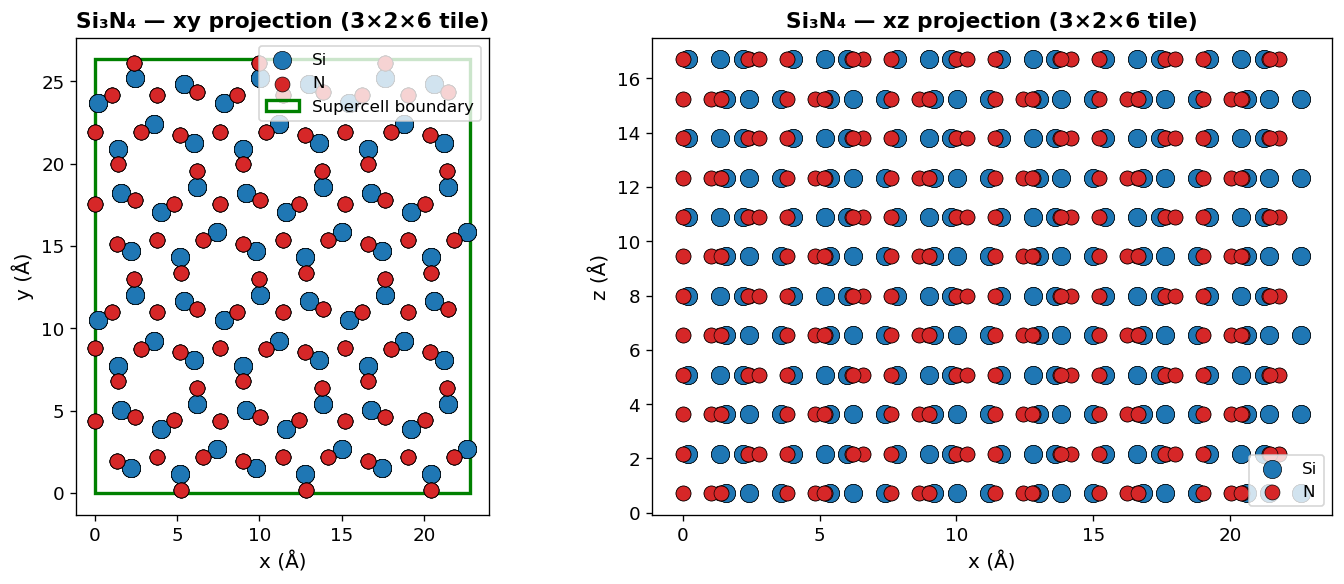

Structure visualized (3×2×6 supercell)


In [3]:
# Visualize tiled supercell (3×2×6 for clarity)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# xy projection
ax = axes[0]
supercell = structure_orthogonal * (3, 2, 6)
pos = supercell.get_positions()
symbols = supercell.get_chemical_symbols()

colors = {'Si': '#1f77b4', 'N': '#ff7f0e'}
sizes  = {'Si': 120, 'N': 80}
for sym, color, size in [('Si', '#1f77b4', 120), ('N', '#d62728', 80)]:
    mask = np.array(symbols) == sym
    ax.scatter(pos[mask, 0], pos[mask, 1], c=color, s=size, label=sym,
               edgecolors='k', linewidths=0.4, zorder=3)

cell_ortho_xy = structure_orthogonal.cell
a, b = cell_ortho_xy[0, 0] * 3, cell_ortho_xy[1, 1] * 2
rect = plt.Rectangle((0, 0), a, b, fill=False, edgecolor='green',
                      linewidth=2, label='Supercell boundary')
ax.add_patch(rect)
ax.set_xlabel('x (Å)')
ax.set_ylabel('y (Å)')
ax.set_title('Si₃N₄ — xy projection (3×2×6 tile)', fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')

# xz projection
ax = axes[1]
for sym, color, size in [('Si', '#1f77b4', 120), ('N', '#d62728', 80)]:
    mask = np.array(symbols) == sym
    ax.scatter(pos[mask, 0], pos[mask, 2], c=color, s=size, label=sym,
               edgecolors='k', linewidths=0.4, zorder=3)
ax.set_xlabel('x (Å)')
ax.set_ylabel('z (Å)')
ax.set_title('Si₃N₄ — xz projection (3×2×6 tile)', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('si3n4_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Structure visualized (3×2×6 supercell)")

## 2. Classical Reference: abTEM Projected Potential

We first compute the classical ground truth using abTEM's `Potential` with FrozenPhonons, matching the parameters from the user's reference workflow.

In [4]:
# --- abTEM FrozenPhonons + Potential ---
N_TILE_Z = 17   # slices along beam (z)
N_PHONON_CONFIGS = 8
SAMPLING = 0.1       # Å/pixel
SLICE_THICK = 2.0    # Å per slice

frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, N_TILE_Z),
    N_PHONON_CONFIGS,
    {'Si': 0.1, 'N': 0.1},
    seed=1,
)

potential = abtem.Potential(
    frozen_phonons,
    sampling=SAMPLING,
    slice_thickness=SLICE_THICK,
    projection='infinite',
    parametrization='kirkland',
)

print(f"Potential grid:       {potential.gpts}  pixels")
print(f"Sampling:             {SAMPLING} Å/pixel")
print(f"Number of slices:     {potential.num_slices}")
print(f"Slice thickness:      {SLICE_THICK} Å")
print(f"Phonon configurations: {N_PHONON_CONFIGS}")

Potential grid:       (229, 264)  pixels
Sampling:             0.1 Å/pixel
Number of slices:     25
Slice thickness:      2.0 Å
Phonon configurations: 8


Projected potential shape: (1, 229, 264)
Potential range: [24.0, 12560.9] V·Å


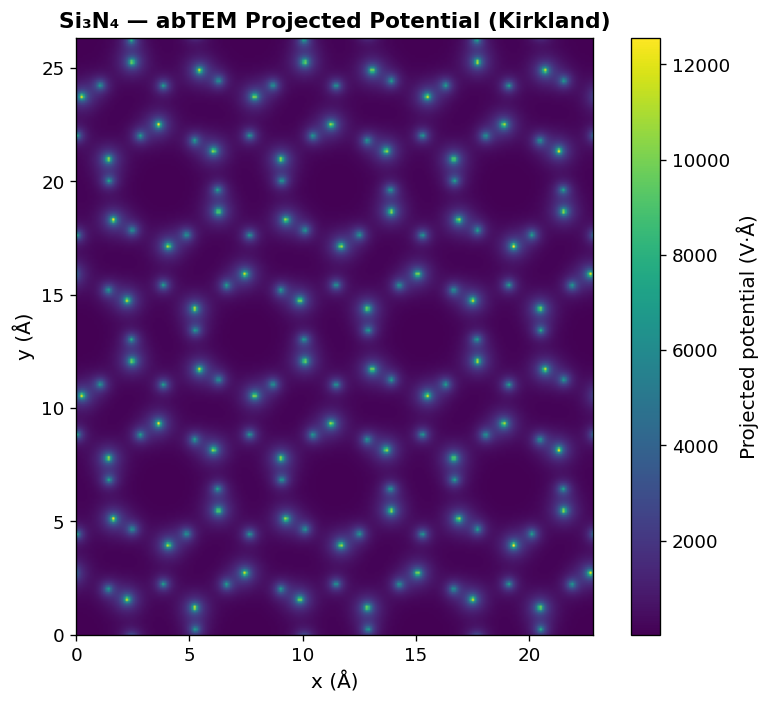

In [5]:
# Build the projected potential directly using abTEM's slice generator (avoids
# NumPy 2.0 incompatibility in abtem.Potential.project().compute()).
import dask
SAMPLING_FINE = 0.1   # Å/pixel — high resolution for classical reference

potential_single = abtem.Potential(
    structure_orthogonal * (3, 2, N_TILE_Z),
    sampling=SAMPLING_FINE,
    slice_thickness=SLICE_THICK,
    projection='infinite',
    parametrization='kirkland',
)

# Accumulate slice arrays without calling .compute() on the ensemble wrapper
V_proj_accum = None
for pot_slice in potential_single.generate_slices():
    arr = np.array(pot_slice.array)   # triggers dask compute per-slice (no ensemble)
    if V_proj_accum is None:
        V_proj_accum = arr
    else:
        V_proj_accum += arr

print(f"Projected potential shape: {V_proj_accum.shape}")
print(f"Potential range: [{V_proj_accum.min():.1f}, {V_proj_accum.max():.1f}] V·Å")

extent_x = structure_orthogonal.cell[0, 0] * 3
extent_y = structure_orthogonal.cell[1, 1] * 2

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    V_proj_accum.T,
    cmap='viridis',
    extent=[0, extent_x, 0, extent_y],
    origin='lower'
)
plt.colorbar(im, ax=ax, label='Projected potential (V·Å)')
ax.set_xlabel('x (Å)')
ax.set_ylabel('y (Å)')
ax.set_title('Si₃N₄ — abTEM Projected Potential (Kirkland)', fontweight='bold')
plt.tight_layout()
plt.savefig('si3n4_abtem_potential.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Quantum Multislice Parameters

We now set up the quantum simulation. For a tractable circuit (statevector simulation scales as $2^{n}$), we use a **16×16 grid (8 qubits)** over one orthogonal unit cell. Larger grids (64×64 = 12 qubits) follow the same code — just change `grid_size`.

Relativistic wavelength:  0.0251 Å
Interaction constant σ:   0.0007 V⁻¹Å⁻¹
Grid:                     128×128  (14 qubits)
Real-space extent:        64.0 × 64.0 Å²
Defocus (current):        -3000 Å
  (Scherzer = -659.7 Å for 200 kV, Cs=1.3 mm)


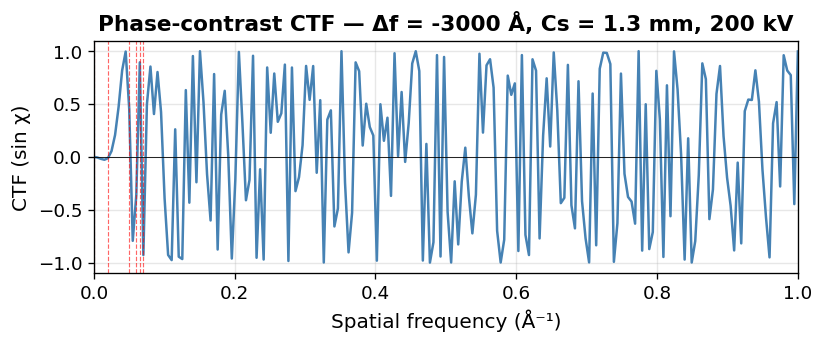

First CTF zero at k ≈ 0.000 Å⁻¹  →  d = inf Å  (point resolution)


In [6]:

# Physical microscope parameters — 200 kV FEG-TEM
ACCELERATION_VOLTAGE = 200e3  # V
CS_MM  = 1.3                  # mm  (Scherzer Cs)

# ── Defocus sweep — try different values to maximise atom-column contrast ──
# Scherzer = -659.7 Å  (optimal phase-contrast for 200 kV, Cs=1.3 mm)
# More underfocus (−1500 → −3000 Å) boosts low-freq contrast but blurs fine detail
# In-focus (0 Å) gives amplitude contrast only → very weak for light atoms
DEFOCUS_A = -3000            # Å  ← change this to explore (e.g. -1500, -2000, -3000)

# Quantum grid — must be power of 2 in each dimension
GRID_SIZE   = 128   # 16×16 = 8 qubits  (demo); use 64 for publication quality
PIXEL_SIZE  = 0.5   # Å/pixel
Q_SLICE_THICK = 2.9052  # Å  — one unit cell along c-axis

params = QuantumMultisliceParameters(
    acceleration_voltage=ACCELERATION_VOLTAGE,
    grid_size=GRID_SIZE,
    pixel_size=PIXEL_SIZE,
    defocus=DEFOCUS_A,
    cs=CS_MM,
    slice_thickness=Q_SLICE_THICK,
)

from quscope.quantum_ctem.quantum_ctem_circuit import relativistic_wavelength, interaction_constant
wavelength = relativistic_wavelength(ACCELERATION_VOLTAGE)
sigma      = interaction_constant(ACCELERATION_VOLTAGE, wavelength)

print(f"Relativistic wavelength:  {wavelength:.4f} Å")
print(f"Interaction constant σ:   {sigma:.4f} V⁻¹Å⁻¹")
print(f"Grid:                     {GRID_SIZE}×{GRID_SIZE}  ({2*int(np.log2(GRID_SIZE))} qubits)")
print(f"Real-space extent:        {GRID_SIZE*PIXEL_SIZE:.1f} × {GRID_SIZE*PIXEL_SIZE:.1f} Å²")
print(f"Defocus (current):        {DEFOCUS_A} Å")
print(f"  (Scherzer = -659.7 Å for 200 kV, Cs=1.3 mm)")

# ── Quick CTF diagnostic ───────────────────────────────────────────────────
k = np.linspace(0, 1/(2*PIXEL_SIZE), 200)                # Å⁻¹
chi = np.pi * wavelength * (DEFOCUS_A * k**2 + 0.5 * CS_MM*1e7 * k**4)
ctf = np.sin(chi)       # imaginary part of transfer function (phase contrast)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(k, ctf, 'steelblue', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Spatial frequency (Å⁻¹)')
ax.set_ylabel('CTF (sin χ)')
ax.set_title(f'Phase-contrast CTF — Δf = {DEFOCUS_A:.0f} Å, Cs = {CS_MM} mm, {ACCELERATION_VOLTAGE/1e3:.0f} kV',
             fontweight='bold')
ax.set_xlim(0, 1/(2*PIXEL_SIZE))
ax.grid(alpha=0.3)
# Mark zero crossings
zeros = np.where(np.diff(np.sign(ctf)))[0]
for z in zeros[:6]:
    ax.axvline(k[z], color='red', lw=0.7, ls='--', alpha=0.6)
plt.tight_layout()
plt.show()
print(f"First CTF zero at k ≈ {k[zeros[0]]:.3f} Å⁻¹  →  d = {1/k[zeros[0]]:.2f} Å  (point resolution)")


## 4. Slice Potentials via Kirkland Parameterization

Each slice's projected potential $V(x,y)$ is computed using the Kirkland parameterization for Si (Z=14) and N (Z=7), then used as the phase grating in the quantum circuit:

$$T_n(x,y) = e^{i\sigma V_n(x,y)}$$

In [7]:
def build_si3n4_slice_potentials(
    structure_orth: ase.Atoms,
    grid_size: int,
    pixel_size: float,
    slice_thickness: float,
    n_slices: int = 4,
) -> list:
    """
    Build a list of 2D projected potentials for each slice along z.

    Atoms are assigned to slices by their fractional z-coordinate.
    The potential is computed with the Kirkland parameterization.

    Args:
        structure_orth: Orthogonal ASE Atoms object
        grid_size:  N — pixels per side (must be power of 2)
        pixel_size: Å per pixel
        slice_thickness: Å per slice
        n_slices: Number of slices

    Returns:
        List of n_slices 2D numpy arrays (shape = grid_size × grid_size)
    """
    kirk = KirklandPotential()
    
    extent = grid_size * pixel_size   # Å  (same in x and y)
    x_lin = np.linspace(0, extent, grid_size, endpoint=False)
    y_lin = np.linspace(0, extent, grid_size, endpoint=False)
    X, Y  = np.meshgrid(x_lin, y_lin, indexing='ij')  # (N, N)

    Z_total = structure_orth.cell[2, 2]   # total thickness in Å
    z_bounds = np.linspace(0, Z_total, n_slices + 1)

    # Map element symbol → atomic number (only Si and N needed)
    SYMBOL_Z = {'Si': 14, 'N': 7}

    positions = structure_orth.get_positions()       # (M, 3)
    symbols   = structure_orth.get_chemical_symbols()
    cell_x    = structure_orth.cell[0, 0]            # Å
    cell_y    = structure_orth.cell[1, 1]            # Å

    slice_potentials = []
    for s in range(n_slices):
        z_lo, z_hi = z_bounds[s], z_bounds[s + 1]
        V = np.zeros((grid_size, grid_size))

        for pos, sym in zip(positions, symbols):
            if z_lo <= pos[2] < z_hi and sym in SYMBOL_Z:
                # Wrap atom x/y into the simulation box
                ax = pos[0] % cell_x
                ay = pos[1] % cell_y
                # Tile atom periodically across the simulation grid
                for nx in range(int(np.ceil(extent / cell_x)) + 1):
                    for ny in range(int(np.ceil(extent / cell_y)) + 1):
                        atom_px = ax + nx * cell_x
                        atom_py = ay + ny * cell_y
                        if -3 < atom_px < extent + 3 and -3 < atom_py < extent + 3:
                            V += kirk.calculate_2d(X, Y, atom_px, atom_py,
                                                   SYMBOL_Z[sym])
        slice_potentials.append(V)

    return slice_potentials


# Build slice potentials for one unit cell along c (4 slices)
N_SLICES = 4
print(f"Computing {N_SLICES} slice potentials on {GRID_SIZE}×{GRID_SIZE} grid…")

slice_pots = build_si3n4_slice_potentials(
    structure_orthogonal,
    grid_size=GRID_SIZE,
    pixel_size=PIXEL_SIZE,
    slice_thickness=Q_SLICE_THICK / N_SLICES,
    n_slices=N_SLICES,
)

for i, V in enumerate(slice_pots):
    print(f"  Slice {i+1}: V ∈ [{V.min():.1f}, {V.max():.1f}] V, "
          f"σV_max = {sigma * V.max():.3f} rad")

Computing 4 slice potentials on 128×128 grid…


  Slice 1: V ∈ [0.0, 2497.3] V, σV_max = 1.820 rad
  Slice 2: V ∈ [0.0, 0.0] V, σV_max = 0.000 rad
  Slice 3: V ∈ [0.2, 2628.9] V, σV_max = 1.916 rad
  Slice 4: V ∈ [0.0, 0.0] V, σV_max = 0.000 rad


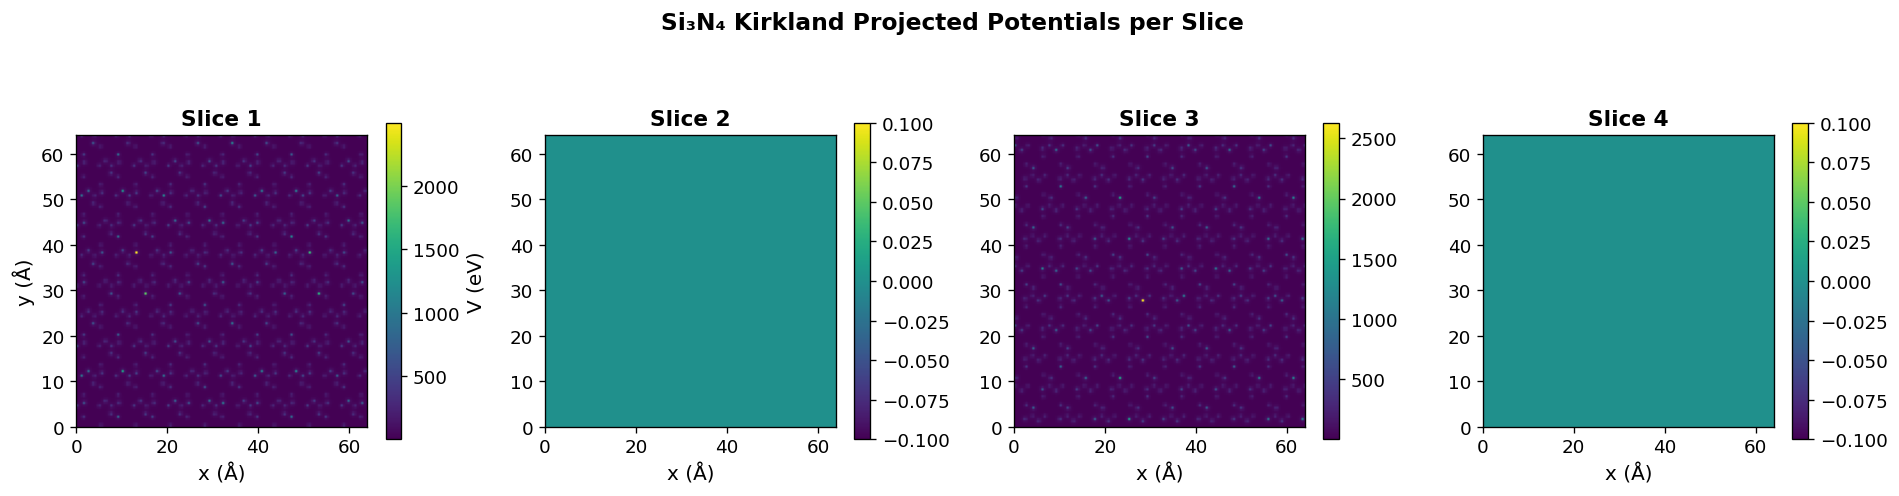

In [8]:
# Visualize slice potentials
fig, axes = plt.subplots(1, N_SLICES, figsize=(4 * N_SLICES, 4))
extent_ax = [0, GRID_SIZE * PIXEL_SIZE, 0, GRID_SIZE * PIXEL_SIZE]

for i, (ax, V) in enumerate(zip(axes, slice_pots)):
    im = ax.imshow(V.T, cmap='viridis', origin='lower', extent=extent_ax)
    plt.colorbar(im, ax=ax, shrink=0.8, label='V (eV)' if i == 0 else '')
    ax.set_title(f'Slice {i+1}', fontweight='bold')
    ax.set_xlabel('x (Å)')
    if i == 0:
        ax.set_ylabel('y (Å)')

fig.suptitle('Si₃N₄ Kirkland Projected Potentials per Slice', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('si3n4_slice_potentials.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Quantum Multislice Circuit — Run Simulation

The quantum circuit propagates the electron wavefunction slice-by-slice using DiagonalGate (phase grating, Fresnel propagator, CTF) and QFT / IQFT gates.

In [9]:
# Build and inspect circuit
sim = QuantumMultisliceCircuit(params)
qc  = sim.build_full_circuit(slice_pots, include_barriers=True)

print(f"Circuit depth:    {qc.depth()}")
print(f"Gate count:       {qc.size()}")
print(f"Qubits:           {qc.num_qubits}")

# Draw circuit (text mode for compact output)
print("\nCircuit diagram (first 30 lines):")
circuit_str = qc.draw(output='text', fold=120).__str__()
print('\n'.join(circuit_str.split('\n')[:30]))
print('...')

Circuit depth:    17
Gate count:       38
Qubits:           14

Circuit diagram (first 30 lines):


      ┌───┐ |ψ_in⟩ »
 q_0: ┤ H ├───░────»
      ├───┤   ░    »
 q_1: ┤ H ├───░────»
      ├───┤   ░    »
 q_2: ┤ H ├───░────»
      ├───┤   ░    »
 q_3: ┤ H ├───░────»
      ├───┤   ░    »
 q_4: ┤ H ├───░────»
      ├───┤   ░    »
 q_5: ┤ H ├───░────»
      ├───┤   ░    »
 q_6: ┤ H ├───░────»
      ├───┤   ░    »
 q_7: ┤ H ├───░────»
      ├───┤   ░    »
 q_8: ┤ H ├───░────»
      ├───┤   ░    »
 q_9: ┤ H ├───░────»
      ├───┤   ░    »
q_10: ┤ H ├───░────»
      ├───┤   ░    »
q_11: ┤ H ├───░────»
      ├───┤   ░    »
q_12: ┤ H ├───░────»
      ├───┤   ░    »
q_13: ┤ H ├───░────»
      └───┘   ░    »
«      ┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [10]:
# Run statevector simulation
print(f"Running quantum simulation ({GRID_SIZE}×{GRID_SIZE}, {N_SLICES} slices)…")
result = sim.simulate(slice_pots)

psi_q   = result['wave_function']   # complex (N, N)
I_q     = result['intensity']       # |ψ|² (N, N)
amp_q   = result['amplitude']
phase_q = result['phase']

print(f"Wave function shape:     {psi_q.shape}")
print(f"Intensity range:         [{I_q.min():.4e}, {I_q.max():.4e}]")
print(f"Phase range:             [{phase_q.min():.3f}, {phase_q.max():.3f}] rad")
print(f"Norm (should be 1.0):    {np.sum(I_q):.6f}")

Running quantum simulation (128×128, 4 slices)…


Wave function shape:     (128, 128)
Intensity range:         [3.7227e-05, 9.5214e-05]
Phase range:             [-0.180, 0.244] rad
Norm (should be 1.0):    1.000000


## 6. Classical Baseline (NumPy Multislice)

We run the equivalent classical multislice in NumPy to validate the quantum result.

In [11]:
# Classical multislice via QuantumClassicalMultisliceValidator
validator = QuantumClassicalMultisliceValidator(params)
psi_c     = validator.classical_multislice(slice_pots)
I_c       = np.abs(psi_c)**2

print(f"Classical intensity range: [{I_c.min():.4e}, {I_c.max():.4e}]")
print(f"Classical norm:            {np.sum(I_c):.6f}")

Classical intensity range: [3.7227e-05, 9.5214e-05]
Classical norm:            1.000000


In [12]:
# Compute quantum–classical fidelity
comparison = validator.compare(slice_pots)
fidelity   = comparison['fidelity']
rmse       = comparison['rmse']

print(f"Quantum–Classical Fidelity : {fidelity:.6f}")
print(f"RMSE (wave function)       : {rmse:.6e}")

if fidelity > 0.999:
    print("✓ Excellent agreement (fidelity > 0.999)")
elif fidelity > 0.99:
    print("✓ Good agreement (fidelity > 0.99)")
else:
    print(f"! Moderate agreement (fidelity = {fidelity:.4f}); "
          "check grid resolution and slice thickness")

Quantum–Classical Fidelity : 1.000000
RMSE (wave function)       : 5.220661e-16
✓ Excellent agreement (fidelity > 0.999)


## 7. Results

Side-by-side comparison of quantum and classical simulated images.

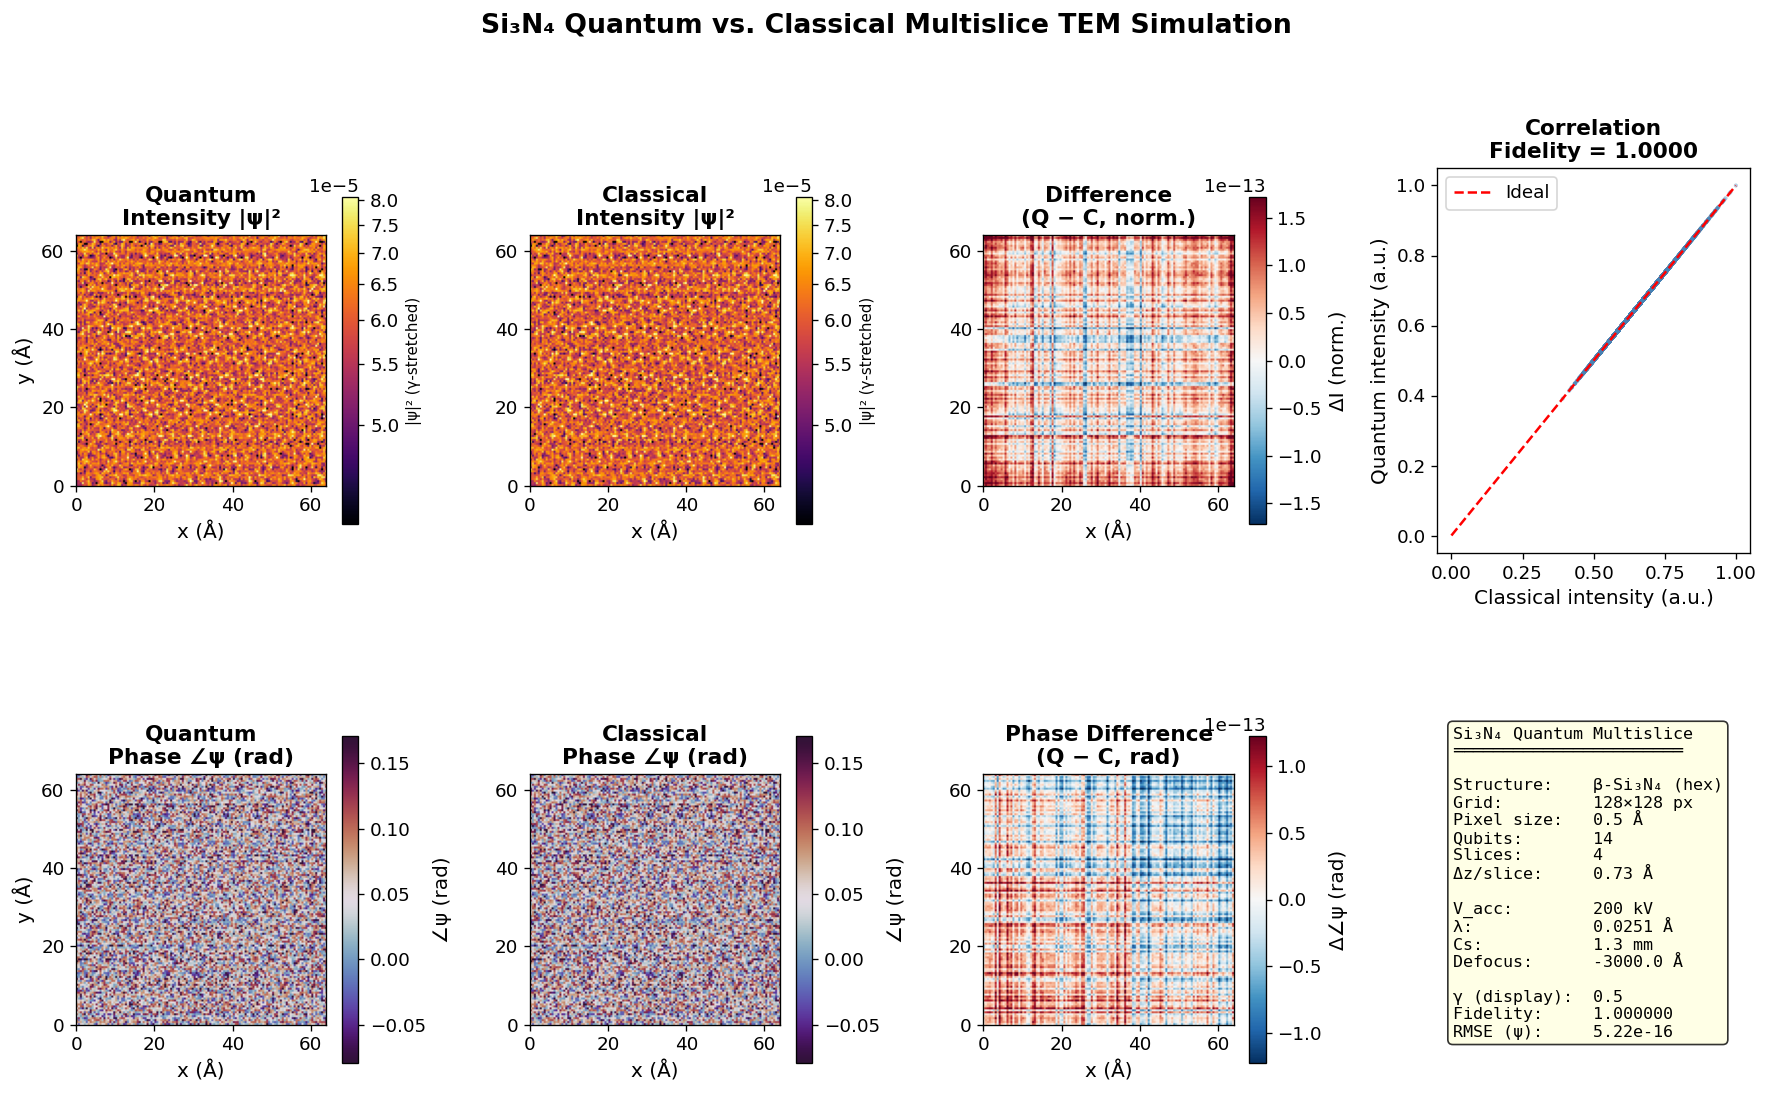

Results saved to si3n4_quantum_multislice_results.png

Intensity contrast  — Q: [3.723e-05, 9.521e-05]    C: [3.723e-05, 9.521e-05]
Phase range         — Q: [-0.1805, 0.2444] rad    C: [-0.1805, 0.2444] rad


In [13]:
from matplotlib.colors import PowerNorm

def contrast_stretch(data, lo=1, hi=99):
    """Percentile-clip then rescale to [0, 1] for display."""
    vmin, vmax = np.percentile(data, lo), np.percentile(data, hi)
    return np.clip((data - vmin) / (vmax - vmin + 1e-30), 0, 1), vmin, vmax

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.40, wspace=0.45)
ext = [0, GRID_SIZE * PIXEL_SIZE, 0, GRID_SIZE * PIXEL_SIZE]

# ── Contrast-stretched intensity (γ = 0.5 brightens dim atom-column signal) ──
gamma = 0.5

# Row 0 — intensity
ax0 = fig.add_subplot(gs[0, 0])
_, vmin_q, vmax_q = contrast_stretch(I_q)
im0 = ax0.imshow(I_q.T, cmap='inferno', origin='lower', extent=ext,
                 norm=PowerNorm(gamma=gamma, vmin=vmin_q, vmax=vmax_q))
cb0 = plt.colorbar(im0, ax=ax0, shrink=0.85)
cb0.set_label('|ψ|² (γ-stretched)', fontsize=9)
ax0.set_title('Quantum\nIntensity |ψ|²', fontweight='bold')
ax0.set_xlabel('x (Å)'); ax0.set_ylabel('y (Å)')

ax1 = fig.add_subplot(gs[0, 1])
_, vmin_c, vmax_c = contrast_stretch(I_c)
im1 = ax1.imshow(I_c.T, cmap='inferno', origin='lower', extent=ext,
                 norm=PowerNorm(gamma=gamma, vmin=vmin_c, vmax=vmax_c))
cb1 = plt.colorbar(im1, ax=ax1, shrink=0.85)
cb1.set_label('|ψ|² (γ-stretched)', fontsize=9)
ax1.set_title('Classical\nIntensity |ψ|²', fontweight='bold')
ax1.set_xlabel('x (Å)')

# Difference — use symmetric percentile clipping
I_q_norm = I_q / I_q.max()
I_c_norm = I_c / I_c.max()
diff     = I_q_norm - I_c_norm
vlim     = np.percentile(np.abs(diff), 99)

ax2 = fig.add_subplot(gs[0, 2])
im2 = ax2.imshow(diff.T, cmap='RdBu_r', origin='lower', extent=ext,
                 vmin=-vlim, vmax=vlim)
plt.colorbar(im2, ax=ax2, shrink=0.85, label='ΔI (norm.)')
ax2.set_title('Difference\n(Q − C, norm.)', fontweight='bold')
ax2.set_xlabel('x (Å)')

# Correlation scatter
ax3 = fig.add_subplot(gs[0, 3])
ax3.scatter(I_c_norm.flatten(), I_q_norm.flatten(),
            alpha=0.4, s=6, color='steelblue', edgecolors='none')
lim = [0, max(I_c_norm.max(), I_q_norm.max())]
ax3.plot(lim, lim, 'r--', label='Ideal')
ax3.set_xlabel('Classical intensity (a.u.)')
ax3.set_ylabel('Quantum intensity (a.u.)')
ax3.set_title(f'Correlation\nFidelity = {fidelity:.4f}', fontweight='bold')
ax3.legend()

# Row 1 — phase (use actual data range, not fixed ±π which hides tiny values)
phase_c = np.angle(psi_c)

p_lo, p_hi = np.percentile(phase_q, 1), np.percentile(phase_q, 99)
ax4 = fig.add_subplot(gs[1, 0])
im4 = ax4.imshow(phase_q.T, cmap='twilight_shifted', origin='lower', extent=ext,
                 vmin=p_lo, vmax=p_hi)
plt.colorbar(im4, ax=ax4, shrink=0.85, label='∠ψ (rad)')
ax4.set_title('Quantum\nPhase ∠ψ (rad)', fontweight='bold')
ax4.set_xlabel('x (Å)'); ax4.set_ylabel('y (Å)')

pc_lo, pc_hi = np.percentile(phase_c, 1), np.percentile(phase_c, 99)
ax5 = fig.add_subplot(gs[1, 1])
im5 = ax5.imshow(phase_c.T, cmap='twilight_shifted', origin='lower', extent=ext,
                 vmin=pc_lo, vmax=pc_hi)
plt.colorbar(im5, ax=ax5, shrink=0.85, label='∠ψ (rad)')
ax5.set_title('Classical\nPhase ∠ψ (rad)', fontweight='bold')
ax5.set_xlabel('x (Å)')

# Phase difference
phase_diff = (phase_q - phase_c + np.pi) % (2 * np.pi) - np.pi
pd_lim = np.percentile(np.abs(phase_diff), 99)
ax6 = fig.add_subplot(gs[1, 2])
im6 = ax6.imshow(phase_diff.T, cmap='RdBu_r', origin='lower', extent=ext,
                 vmin=-pd_lim, vmax=pd_lim)
plt.colorbar(im6, ax=ax6, shrink=0.85, label='Δ∠ψ (rad)')
ax6.set_title('Phase Difference\n(Q − C, rad)', fontweight='bold')
ax6.set_xlabel('x (Å)')

# Summary text box
ax7 = fig.add_subplot(gs[1, 3])
ax7.axis('off')
summary = (
    "Si₃N₄ Quantum Multislice\n"
    "═══════════════════════\n\n"
    f"Structure:    β-Si₃N₄ (hex)\n"
    f"Grid:         {GRID_SIZE}×{GRID_SIZE} px\n"
    f"Pixel size:   {PIXEL_SIZE} Å\n"
    f"Qubits:       {2 * int(np.log2(GRID_SIZE))}\n"
    f"Slices:       {N_SLICES}\n"
    f"Δz/slice:     {Q_SLICE_THICK/N_SLICES:.2f} Å\n\n"
    f"V_acc:        {ACCELERATION_VOLTAGE/1e3:.0f} kV\n"
    f"λ:            {wavelength:.4f} Å\n"
    f"Cs:           {CS_MM} mm\n"
    f"Defocus:      {DEFOCUS_A:.1f} Å\n\n"
    f"γ (display):  {gamma}\n"
    f"Fidelity:     {fidelity:.6f}\n"
    f"RMSE (ψ):     {rmse:.2e}"
)
ax7.text(0.05, 0.95, summary, transform=ax7.transAxes,
         fontsize=10, fontfamily='monospace',
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Si₃N₄ Quantum vs. Classical Multislice TEM Simulation',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('si3n4_quantum_multislice_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved to si3n4_quantum_multislice_results.png")
print(f"\nIntensity contrast  — Q: [{I_q.min():.3e}, {I_q.max():.3e}]  "
      f"  C: [{I_c.min():.3e}, {I_c.max():.3e}]")
print(f"Phase range         — Q: [{phase_q.min():.4f}, {phase_q.max():.4f}] rad  "
      f"  C: [{phase_c.min():.4f}, {phase_c.max():.4f}] rad")


## 8. Line Profile — Atom Column Contrast

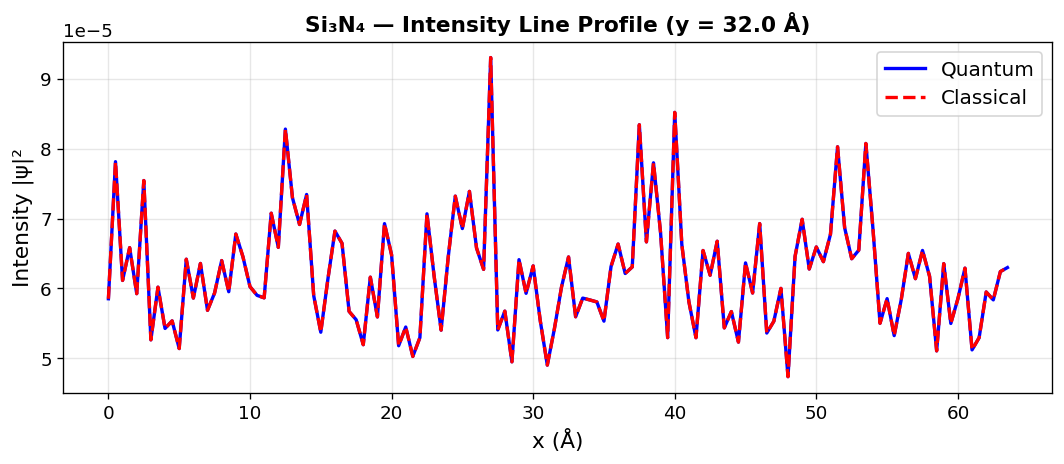

In [14]:
# Central row line profile
row = GRID_SIZE // 2
x_profile = np.arange(GRID_SIZE) * PIXEL_SIZE

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_profile, I_q[row, :], 'b-',  linewidth=2, label='Quantum')
ax.plot(x_profile, I_c[row, :], 'r--', linewidth=2, label='Classical')
ax.set_xlabel('x (Å)', fontsize=13)
ax.set_ylabel('Intensity |ψ|²', fontsize=13)
ax.set_title(f'Si₃N₄ — Intensity Line Profile (y = {row * PIXEL_SIZE:.1f} Å)',
             fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('si3n4_line_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. IBM Quantum Hardware Deployment

Transpile and submit the Si₃N₄ multislice circuit to a real IBM quantum device using **Qiskit Runtime**.

> **Prerequisites:** `pip install qiskit-ibm-runtime`  
> Set `IBM_TOKEN` (or pass your token directly) before running this cell.

### Strategy
- The statevector circuit built in Section 5 uses `DiagonalGate` and `QFT` blocks.  
- `transpile()` decomposes these to the native gate set of the chosen backend.  
- `SamplerV2` samples the final measurement distribution; the probability vector reconstructs $|\psi|^2$.


In [15]:
import os
from pathlib import Path
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime import Session

# ── 1. Authenticate ──────────────────────────────────────────────────────────
# Load credentials from the .env file in the project root.
try:
    from dotenv import load_dotenv
    _nb_dir = Path().resolve()
    for _parent in [_nb_dir, *_nb_dir.parents]:
        _env_file = _parent / ".env"
        if _env_file.exists():
            load_dotenv(_env_file)
            print(f"Loaded .env from: {_env_file}")
            break
    else:
        print("No .env file found — falling back to existing environment variables.")
except ImportError:
    print("python-dotenv not installed. Run: pip install python-dotenv")

IBM_TOKEN = os.getenv("IBMQ_TOKEN") or os.getenv("IBM_TOKEN")
IBM_CRN   = os.getenv("IBM_CRN")

if IBM_TOKEN is None:
    raise EnvironmentError(
        "No IBM token found.\n"
        "Add  IBMQ_TOKEN=<your-api-key>  to the .env file.\n"
        "Get your API key at: https://cloud.ibm.com/iam/apikeys"
    )
print(f"IBM token loaded ✓")
if IBM_CRN:
    print(f"CRN loaded      : {IBM_CRN[:60]}...")
else:
    print("IBM_CRN not set — service will use the default instance.")

# ── 2. Connect to IBM Quantum Platform ───────────────────────────────────────
# Pass instance=IBM_CRN so the service resolves your specific IBM Cloud
# quantum-computing resource instead of searching all accessible instances.
try:
    service = QiskitRuntimeService(
        channel="ibm_quantum_platform",
        token=IBM_TOKEN,
        instance=IBM_CRN,   # CRN pinpoints your IBM Cloud instance
    )
    print("Connected to IBM Quantum Platform ✓")
except Exception as e:
    err_name = type(e).__name__
    if "InvalidAccount" in err_name or "API key" in str(e) or "token" in str(e).lower():
        raise RuntimeError(
            "IBM authentication failed.\n\n"
            "Checklist:\n"
            "  • Token: must be an IBM Cloud API key (not an IBM Quantum Experience token)\n"
            "    → https://cloud.ibm.com/iam/apikeys\n"
            "  • CRN: verify it matches your quantum-computing service instance\n"
            "    → https://cloud.ibm.com/resources  (filter by 'Quantum Computing')\n"
            "  • Update IBMQ_TOKEN and IBM_CRN in your .env file, then restart kernel\n\n"
            f"Original error ({err_name}): {e}"
        ) from e
    raise

# ── 3. Select backend ────────────────────────────────────────────────────────
MIN_QUBITS = 2 * int(np.log2(GRID_SIZE))  # 8 qubits for 16×16 grid

try:
    # Preferred: keyword filters (qiskit-ibm-runtime >= 0.20)
    available = service.backends(
        min_num_qubits=MIN_QUBITS,
        simulator=False,
        operational=True,
    )
except TypeError:
    available = service.backends(
        filters=lambda b: (
            b.num_qubits >= MIN_QUBITS
            and b.status().operational
            and not getattr(b, "simulator", False)
        )
    )

if not available:
    raise RuntimeError(
        f"No operational IBM backend with ≥ {MIN_QUBITS} qubits found.\n"
        "Run  service.backends()  to list all backends accessible on this instance."
    )

backend = service.least_busy(available)
print(f"Selected backend : {backend.name}")
print(f"Qubits available : {backend.num_qubits}")
basis = getattr(backend, "basis_gates", None) or getattr(
    getattr(backend, "target", None), "operation_names", ["(unavailable)"]
)
print(f"Basis gates      : {list(basis)[:8]} ...")

# ── 4. Rebuild & transpile circuit ───────────────────────────────────────────
qc_hw = sim.build_full_circuit(slice_pots, include_barriers=False)
qc_hw.measure_all()

qc_transpiled = transpile(
    qc_hw,
    backend=backend,
    optimization_level=3,
    seed_transpiler=42,
)

print(f"\nOriginal  depth : {qc_hw.depth()}")
print(f"Transpiled depth: {qc_transpiled.depth()}")
print(f"Transpiled gates: {qc_transpiled.size()}")

# ── 5. Submit via Qiskit Runtime Sampler ─────────────────────────────────────
N_SHOTS = 8192

with Session(service=service, backend=backend) as session:
    sampler = Sampler(session=session)
    job = sampler.run([qc_transpiled], shots=N_SHOTS)
    print(f"\nJob ID : {job.job_id()}")
    print("Job submitted — polling for results…")
    result_hw = job.result()

# ── 6. Reconstruct intensity from measurement counts ──────────────────────────
counts = result_hw[0].data.meas.get_counts()
total_shots = sum(counts.values())

N = GRID_SIZE
I_hw = np.zeros((N, N))
for bitstring, count in counts.items():
    idx = int(bitstring, 2)
    ix = idx % N
    iy = idx // N
    if ix < N and iy < N:
        I_hw[ix, iy] += count / total_shots

# ── 7. Visualise hardware vs. statevector ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ext = [0, GRID_SIZE * PIXEL_SIZE, 0, GRID_SIZE * PIXEL_SIZE]

for ax, data, title in zip(
    axes,
    [I_q, I_hw, np.abs(I_q / I_q.max() - I_hw / I_hw.max())],
    ['Statevector (ideal)', f'IBM {backend.name}\n({N_SHOTS} shots)', 'Absolute difference'],
):
    im = ax.imshow(data.T, cmap='inferno', origin='lower', extent=ext)
    plt.colorbar(im, ax=ax, shrink=0.85, label='|ψ|²')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x (Å)')
axes[0].set_ylabel('y (Å)')

fig.suptitle('Si₃N₄ Multislice — Statevector vs. IBM Hardware',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('si3n4_ibm_hardware_results.png', dpi=150, bbox_inches='tight')
plt.show()

I_q_flat  = (I_q  / I_q.sum()).flatten()
I_hw_flat = (I_hw / I_hw.sum()).flatten()
hw_fidelity = float(np.dot(np.sqrt(I_q_flat), np.sqrt(I_hw_flat)) ** 2)
print(f"\nBhattacharyya fidelity (ideal ↔ hardware): {hw_fidelity:.4f}")


qiskit_runtime_service._discover_account:WARNING:2026-07-23 19:20:12,179: Loading account with the given token. A saved account will not be used.


Loaded .env from: /Users/robertoreis/Documents/codes/quantum_algo_microscopy/.env
IBM token loaded ✓
CRN loaded      : crn:v1:bluemix:public:quantum-computing:us-east:a/cec593e718...


RuntimeError: IBM authentication failed.

Checklist:
  • Token: must be an IBM Cloud API key (not an IBM Quantum Experience token)
    → https://cloud.ibm.com/iam/apikeys
  • CRN: verify it matches your quantum-computing service instance
    → https://cloud.ibm.com/resources  (filter by 'Quantum Computing')
  • Update IBMQ_TOKEN and IBM_CRN in your .env file, then restart kernel

Original error (InvalidAccountError): 'Unable to retrieve instances. Please check that you are using a valid API token.'